# Повторные испытания в схеме Бернулли

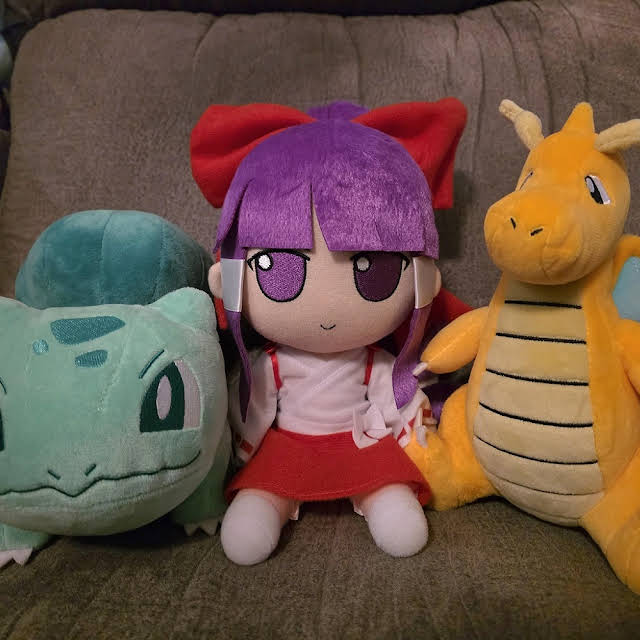

In [1]:
import numpy as np
from scipy.stats import binom, poisson, norm
import matplotlib.pyplot as plt
from math import sqrt

---

## 2.9.

В среднем 20% пакетов акций на аукционах про- даются по первоначально заявленной цене. Найти вероятность того, что из 9 пакетов акций в результате торгов по первоначально заявленной цене: 
* 1) не будут проданы 5 пакетов;
* 2) будет продано:
     * а) менее 2 пакетов;
     * б) не более 2 пакетов;
     * в) хотя бы 2 пакета;
     * г) наивероятнейшее число пакетов.

In [48]:
p = 0.2
q = 1 - p
n = 9

In [10]:
# 1)
prob = binom.pmf(5, n, q)
print(round(prob, 4))

0.0661


In [49]:
# 2)
    # а)
prob = binom.pmf(0, n, p) + binom.pmf(1, n, p)
print(round(prob, 4))

    # б)
prob += binom.pmf(2, n, p)
print(round(prob, 4))

    # в)
# prob = 1 - prob + binom.pmf(2, n, p)
arange = np.arange(2, n+1)
probs = binom.pmf(arange, n, p)
print(round(sum(probs), 4))

    # г)
if (n*p + p) // 1 == n*p + p:
    print(round(binom.pmf(n*p + p, n, p) + binom.pmf(n*p - q, n, p), 4))
else:
    print(max(round(binom.pmf((n*p + p) // 1, n, p) ,4), round(binom.pmf((n*p - q) // 1, n, p) ,4)))

0.4362
0.7382
0.5638
0.604


---

## 2.10.

Завод отправил на базу 10 000 стандартных изделий. Среднее число изделий, повреждаемых при транспортировке, составляет 0,02%. Найти вероятность того, что из 10 000 изделий:
* 1) будет повреждено:
     * а) 3;
     * б) по крайней мере 3;
* 2) не будет повреждено:
     * а) 9997;
     * б) хотя бы 9997.
       

In [58]:
n = 10000
p = 0.0002
q = 1 - p
lamd = n*p
lamd # можно использовать ф. Пуассона

2.0

In [57]:
# 1)
    # а)
m = 3
print(round(poisson.pmf(m, lamd), 4))

    # б)
prob = 1 - sum(poisson.pmf(np.arange(0, m), lamd))
print(round(prob, 4))

0.1804
0.3233


In [66]:
# 2)
    # а)
m = 9997
prob = poisson.pmf(n - m, lamd)
print(round(prob, 4))
    # б)
prob = sum(poisson.pmf(np.arange(0, n - m + 1), lamd))
print(round(prob, 4))

0.1804
0.8571


---

## 2.11.

По результатам проверок налоговыми инспекциями установлено, что в среднем каждое второе малое предприятие региона имеет нарушение финансовой дисциплины. Найти вероятность того, что из 1000 зарегистрированных в регионе малых предприятий имеют нарушения финансовой дисциплины:
* а) 480 предприятий;
* б) наивероятнейшее число предприятий;
* в) не менее 480;
* г) от 480 до 520.

In [70]:
n = 1000
p = 0.5
q = 1 - p
p * n * q # можно использовать локальную ф. Муавра-Лапласа

250.0

In [71]:
# а)
m = 480
x = (m - n * p) / sqrt(n * p * q)
prob = norm.pdf(x) / sqrt(n * p * q)
print(round(prob, 4))

0.0113


In [74]:
# б)
m = max((n * p + p) // 1, (n * p - q) // 1)
x = (m - n * q) / sqrt(n * p * q)
prob = norm.pdf(x) / sqrt(n * p * q)
print(round(prob, 4))

0.0252


In [75]:
# в)
a = 480
b = 1000
x1 = (a - n * p) / sqrt(n * p * q)
x2 = (b - n * p) / sqrt(n * p * q)
prob = norm.cdf(x2) - norm.cdf(x1)
print(round(prob, 4))

0.897


In [76]:
# г)
a = 480
b = 520
x1 = (a - n * p) / sqrt(n * p * q)
x2 = (b - n * p) / sqrt(n * p * q)
prob = norm.cdf(x2) - norm.cdf(x1)
print(round(prob, 4))

0.7941
